In [32]:
classification_names = {
    0: '上身衣服',  # 数字 0 对应“上身衣服”
    1: '鞋',       # 数字 1 对应“鞋”
    2: '包',       # 数字 2 对应“包”
    3: '下身衣服',  # 数字 3 对应“下身衣服”
    4: '手表'      # 数字 4 对应“手表”
}

In [2]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split  # 数据集处理模块

from PIL import Image
import re

In [3]:
# 定义函数：对图片名按字母数字混合排序
def sorted_alphanum(img_names):
    # 转换函数：将数字部分转为int，将字符串转为小写
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda img_name: [convert(x) for x in re.split(r'([0-9]+)', img_name)]
    return sorted(img_names, key=alphanum_key)

# 自定义数据集类型，元素（image, label）
class ImageLabelDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.main_dir = image_dir
        self.transform = transform
        self.image_names = sorted_alphanum(os.listdir(image_dir))  # 获取目录下所有图片文件名，并按字母数字混合排序
        self.labels = pd.read_csv('../common/fashion-labels.csv')      # 读取分类标签csv文件，得到DataFrame
        self.label_dict = dict(zip(self.labels['id'], self.labels['target']))   # 从DataFrame中分离id和标签，得到字典

    def __len__(self):
        return len(self.image_names)

    # 传入图片id，获取数据集元素 （x, y）
    def __getitem__(self, idx):
        # 1. 根据索引号，构建图片的完整路径
        image_loc = os.path.join(self.main_dir, self.image_names[idx])
        # 2. 使用 PIL 打开图片
        image = Image.open(image_loc).convert('RGB')
        # 3. 利用transform转换成tensor
        if self.transform is not None:
            tensor_img = self.transform(image)
        else:
            # 如果为None，就抛出异常
            raise ValueError("transform 参数不能为 None！")
        # 4. 在字典中找出图片对应的标签
        label = self.label_dict[idx]

        # 返回 (噪声图片，原始图片)
        return tensor_img, label

In [4]:
import torchvision.transforms as T  # 图像预处理模块

# 测试主流程
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])

# 1. 创建数据集
full_dataset = ImageLabelDataset(image_dir='../common/dataset/', transform=transform)
print(len(full_dataset))

24853


In [6]:
# 2. 划分数据集
train_dataset, test_dataset = random_split(full_dataset, [0.75, 0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [7]:
# 3. 创建DataLoader
batch_size = 32
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size)

In [8]:
for (x, y) in train_loader:
    print("x shape: ", x.shape)
    print("y shape: ", y.shape)
    break

x shape:  torch.Size([32, 3, 64, 64])
y shape:  torch.Size([32])


In [21]:
import torch.nn as nn

# 定义模型
class Classifier(nn.Module):
    def __init__(self, n_classes=5):
        super(Classifier, self).__init__()
        # 卷积层
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        # 通用池化层
        self.pool = nn.MaxPool2d(2, 2)
        # 全连接层
        self.linear = nn.Linear(16 * 16 * 16, n_classes)
    
    def forward(self, x):
        # 第一层卷积
        x = torch.relu(self.conv1(x))
        # print("第一卷积层输出形状：", x.shape)
        # 第一层池化
        x = self.pool(x)
        # print("第一池化层输出形状：", x.shape)
        # 第二层卷积
        x = torch.relu(self.conv2(x))
        # print("第二卷积层输出形状：", x.shape)
        # 第二层池化
        x = self.pool(x)
        # print("第二池化层输出形状：", x.shape)
        # 扁平化处理：将三维张量展开为一维向量
        x = x.reshape(x.shape[0], -1)
        # print("展开为一维向量形状：", x.shape)
        # 全连接层
        x = self.linear(x)
        # print("全连接层输出形状：", x.shape)
        return x 

In [22]:
model = Classifier()
print(model)

Classifier(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear): Linear(in_features=4096, out_features=5, bias=True)
)


In [23]:
# 获取一个批次数据进行测试
data_iter = iter(train_loader)
x, y = next(data_iter)
print(x.shape, y.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])


In [24]:
# 前向传播
output = model(x)
print(output.shape)

torch.Size([32, 5])


In [15]:
# 定义模型
class Classifier1(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, n_classes)
        )
    
    def forward(self, x):
        return self.model(x)

In [16]:
model1 = Classifier1()
print(model1)

Classifier1(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=5, bias=True)
  )
)


In [18]:
# 前向传播
output = model1(x)
print(output.shape)

torch.Size([32, 5])


In [25]:
# 训练模型
# 定义损失函数和优化器
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# 训练轮次
num_epochs = 10
model.to(device)

Classifier(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear): Linear(in_features=4096, out_features=5, bias=True)
)

In [26]:
for epoch in range(1, num_epochs + 1):
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)   # 前向传播
        loss_value = loss(output, y)    # 计算损失
        loss_value.backward()   # 反向传播
        optimizer.step()    # 更新参数
        optimizer.zero_grad()   # 梯度清零
        train_loss += loss_value.item()
    this_loss = train_loss / len(train_loader)
    print('Epoch {}/{}, Loss: {:.6f}'.format(epoch, num_epochs, this_loss))

Epoch 1/10, Loss: 0.224729
Epoch 2/10, Loss: 0.077464
Epoch 3/10, Loss: 0.061576
Epoch 4/10, Loss: 0.051571
Epoch 5/10, Loss: 0.041483
Epoch 6/10, Loss: 0.036279
Epoch 7/10, Loss: 0.031218
Epoch 8/10, Loss: 0.026896
Epoch 9/10, Loss: 0.020794
Epoch 10/10, Loss: 0.017954


In [27]:
# 验证测试
loader_iter = iter(test_loader)
images, labels = next(loader_iter)
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [29]:
model.to(device)
images = images.to(device)
# 前向传播，计算输出
outputs = model(images)
outputs = outputs.detach().cpu().numpy()
print(outputs.shape)

(32, 5)


In [30]:
images = images.permute(0, 2, 3, 1).detach().cpu().numpy()
print(images.shape)

(32, 64, 64, 3)


1-label: 上身衣服
1-outputs: [  7.6312695 -11.500334   -4.722323   -6.9302573  -7.133948 ]
1-predicted: 上身衣服

2-label: 鞋
2-outputs: [-14.129278    16.364752     0.95257884 -12.274595    -6.0486445 ]
2-predicted: 鞋

3-label: 包
3-outputs: [ -5.166609   -1.7258673   7.74679   -14.130598   -4.733548 ]
3-predicted: 包

4-label: 上身衣服
4-outputs: [  8.7510195 -20.319794   -8.701027   -4.3218045 -12.314137 ]
4-predicted: 上身衣服

5-label: 鞋
5-outputs: [-12.836005   10.2514105   4.711502   -7.044281   -7.7836843]
5-predicted: 鞋

6-label: 上身衣服
6-outputs: [ 13.393083 -15.138496 -14.350071 -14.251953 -12.875893]
6-predicted: 上身衣服

7-label: 鞋
7-outputs: [-6.0554895  3.8410873 -6.933715  -2.0906582 -4.8049107]
7-predicted: 鞋

8-label: 鞋
8-outputs: [-11.284671   12.895901    0.6088223 -10.365026   -7.189729 ]
8-predicted: 鞋

9-label: 手表
9-outputs: [ -3.7854137 -28.80337    -9.137083   -0.6484412   9.532352 ]
9-predicted: 手表

10-label: 下身衣服
10-outputs: [-5.367786  -5.4240685 -4.6744084 -4.4893274 -5.2838497]
1

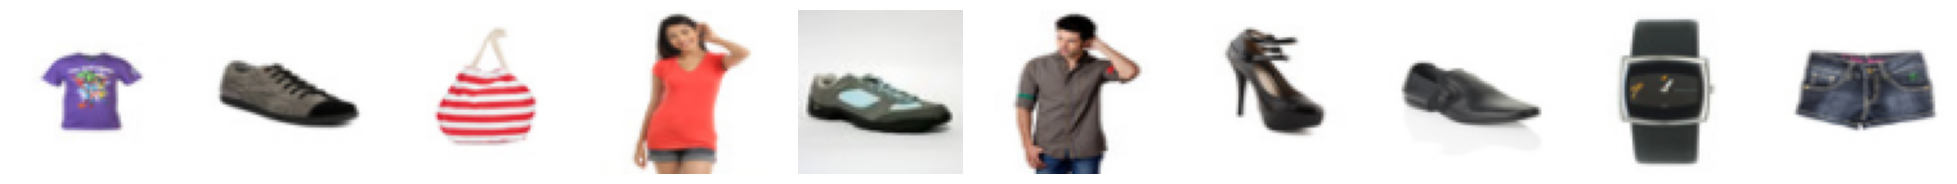

In [35]:
import matplotlib.pyplot as plt
# 画图
fig, axes = plt.subplots(1, 10, figsize=(25, 4))
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis('off')
    # 打印真实分类标签
    print(f"{i+1}-label: {classification_names[int(labels[i])]}")
    # 打印预测值
    y_pred = outputs[i]
    print(f"{i+1}-outputs: {y_pred}")
    # 打印预测分类
    class_pred = np.argmax(y_pred)
    print(f"{i+1}-predicted: {classification_names[class_pred]}")
    print()
plt.show()

In [36]:
# 计算准确率
test_correct_num = 0
with torch.no_grad():
    for (x, y) in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)   # 前向传播
        y_pred = output.argmax(dim=1)   # 获取最大预测值的序号，作为分类号
        test_correct_num += y_pred.eq(y).sum().item()
accuracy = test_correct_num / len(test_dataset)
print("分类准确率：", accuracy)

分类准确率： 0.9884113954611299
